In [51]:
from matplotlib import colormaps
list(colormaps)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("bmw_global_sales_2018_2025.csv")
pd.set_option("Display.max_row", None)
pd.set_option("Display.max_columns", None)
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [4]:
df.tail()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41
3071,2025,12,RestOfWorld,MINI,6732,41811,281471652,0.167,5.89,2.37,1.41


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [6]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [9]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [10]:
df = df.drop_duplicates()

In [11]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [12]:
df.shape

(3072, 11)

**Ques1**. Year-wise Units Sold trend kya hai.

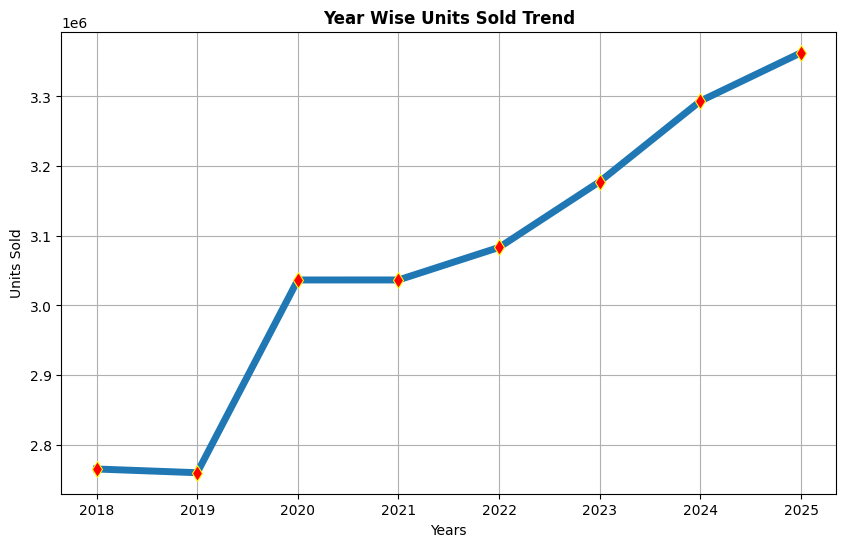

In [29]:
plt.figure(figsize = (10,6))
Year_wise = df.groupby('Year')['Units_Sold'].sum().reset_index()
sns.lineplot(
    data = Year_wise,
    x = 'Year',
    y = 'Units_Sold',
    marker = 'd',
    #palette = 'dark',
    markersize = 8,
    markeredgecolor = 'yellow',
    markerfacecolor = 'red',
    linewidth = 5,
    #hue = 'Year'
    errorbar = ('ci',35)
)
plt.xlabel('Years')
plt.ylabel('Units Sold')
plt.title('Year Wise Units Sold Trend', fontweight = 'bold')
plt.grid(True)
plt.show()

**Ques 2.** Month-wise sales trend kya hai? (Seasonality check).

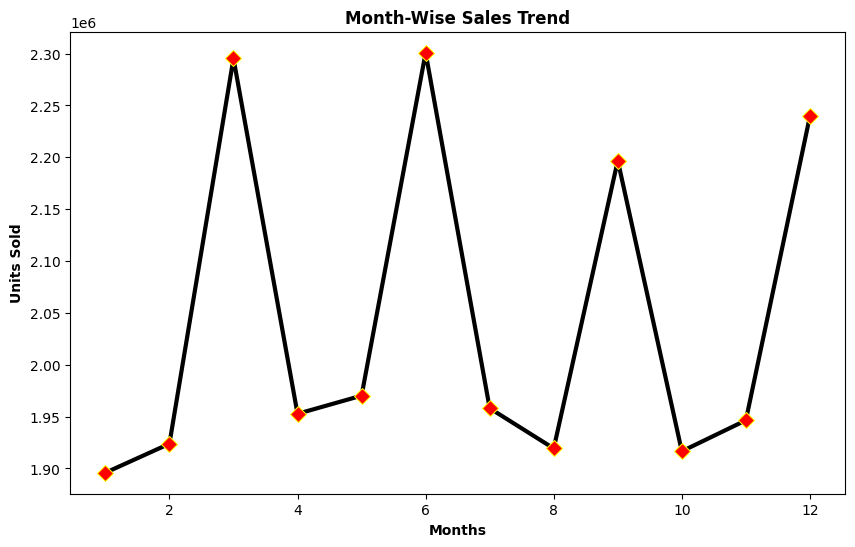

In [36]:
plt.figure(figsize = (10,6) )
Month_wise_sales = df.groupby('Month')['Units_Sold'].sum().reset_index()
sns.lineplot(
    data = Month_wise_sales,
    x = 'Month',
    y = 'Units_Sold',
    marker = 'D',
    markersize = 8,
    markerfacecolor = 'red',
    markeredgecolor = 'yellow',
    linewidth = 3,
    color = 'black',
    errorbar = ('ci',30),
)
plt.title('Month-Wise Sales Trend',fontweight = 'bold')
plt.xlabel('Months',fontweight = 'bold')
plt.ylabel('Units Sold',fontweight = 'bold')
plt.show()

**Ques3.** Total Revenue ka yearly growth rate kya hai?

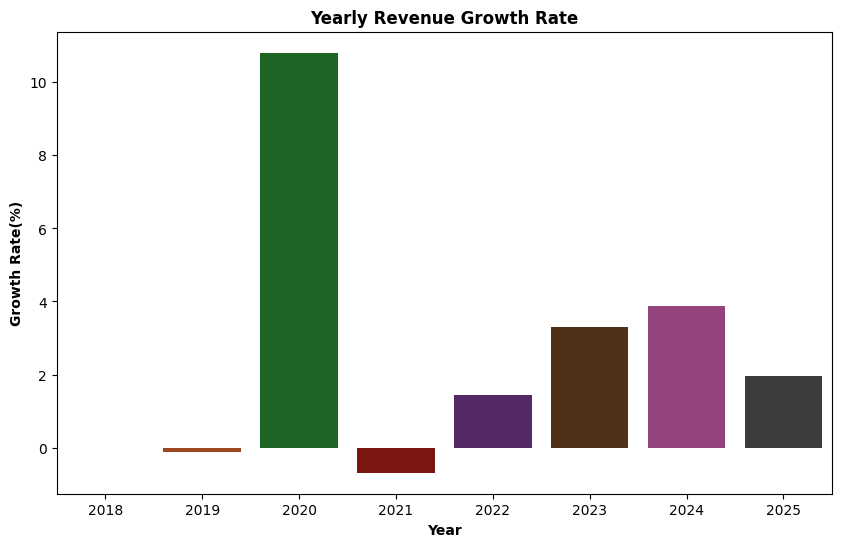

In [55]:
plt.figure(figsize =(10,6) )
Total_Revenue = df.groupby('Year')['Revenue_EUR'].sum().reset_index()
Total_Revenue['Growth_rate_%'] = Total_Revenue['Revenue_EUR'].pct_change()*100
sns.barplot(
    data = Total_Revenue,
    x = 'Year',
    y = 'Growth_rate_%',
    palette = 'dark',
    hue = 'Year',
    legend=False
)
plt.xlabel('Year', fontweight = 'bold')
plt.ylabel('Growth Rate(%)',fontweight = 'bold')
plt.title('Yearly Revenue Growth Rate',fontweight = 'bold')
plt.show()

**Ques 4**.Year aur Month ke basis par sales me kaunse peak months hain?

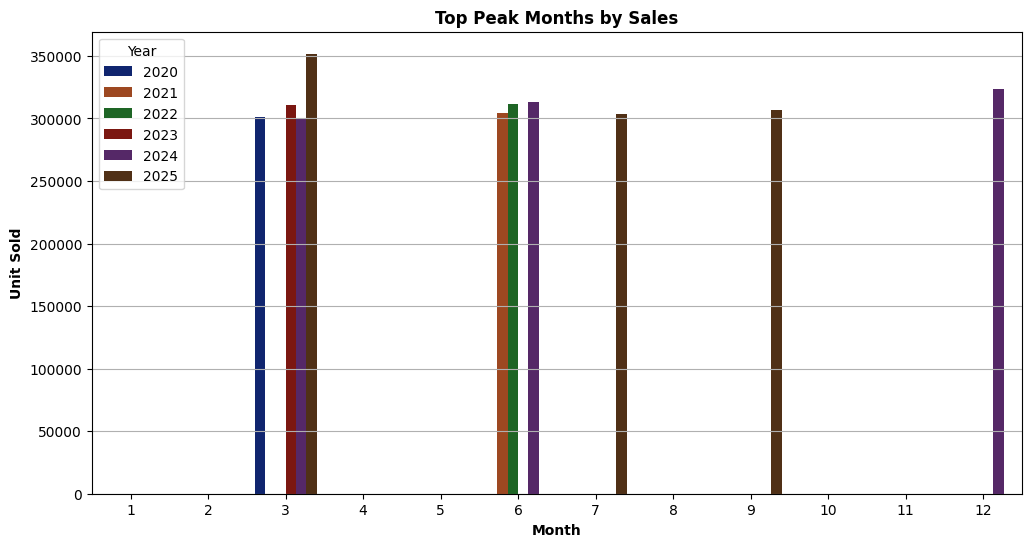

In [80]:
plt.figure(figsize = (12,6))

peak_months = df.groupby(['Year', 'Month'])['Units_Sold'].sum().reset_index()
peak_months = peak_months.sort_values(by='Units_Sold', ascending=False) 
order = sorted(peak_months['Month'].unique())
sns.barplot(
    data = peak_months.head(10),
    x = 'Month',
    y = 'Units_Sold',
    hue = 'Year',
    palette = 'dark',
    order=order
)
plt.xlabel('Month',fontweight = 'bold')
plt.ylabel('Unit Sold',fontweight = 'bold')
plt.title('Top Peak Months by Sales', fontweight = 'bold')
plt.grid(axis='y')
plt.show()

**Ques 5**: Units Sold vs Revenue relationship kya hai?

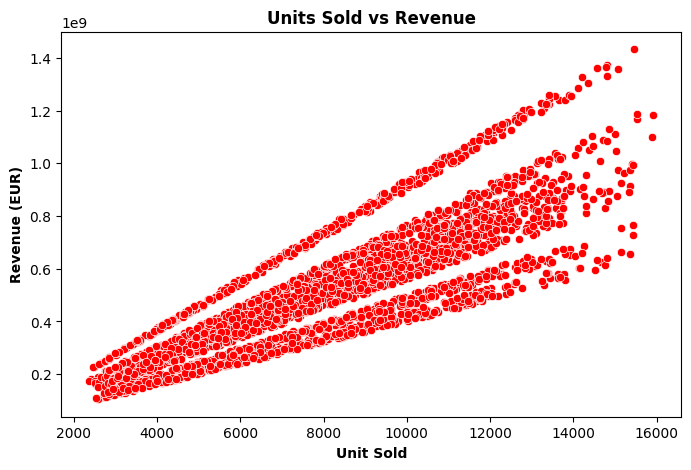

In [90]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data = df,
    x = 'Units_Sold',
    y = 'Revenue_EUR',
    color = 'red'
)
plt.title('Units Sold vs Revenue', fontweight = 'bold')
plt.xlabel('Unit Sold',fontweight = 'bold')
plt.ylabel('Revenue (EUR)',fontweight = 'bold')
plt.show()

**Ques 6.** Kaunsa Region sabse zyada Units Sold karta hai? 

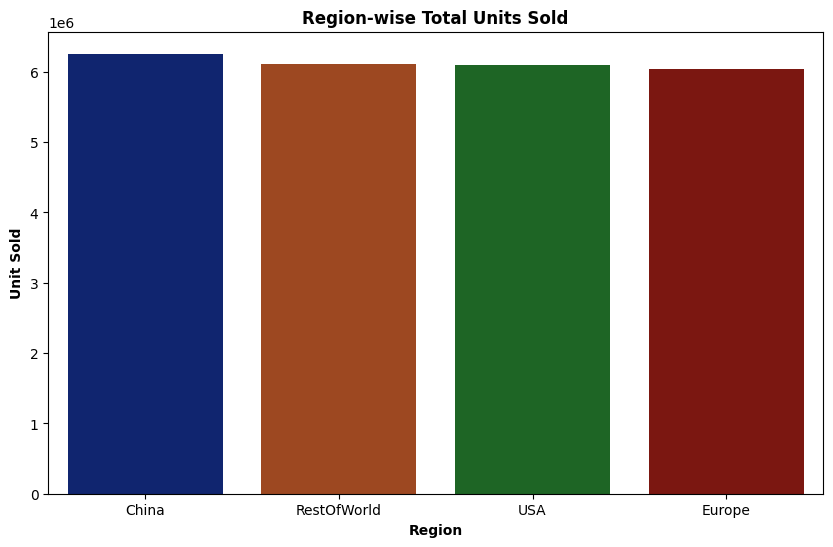

In [98]:
plt.figure(figsize = (10,6))
total_units_sold = df.groupby('Region')['Units_Sold'].sum().reset_index()
total_units_sold = total_units_sold.sort_values(by='Units_Sold', ascending=False)

sns.barplot(
    data = total_units_sold,
    x = 'Region',
    y = 'Units_Sold',
    palette = 'dark',
    hue = 'Region'
)
plt.title('Region-wise Total Units Sold',fontweight = 'bold')
plt.xlabel('Region',fontweight = 'bold')
plt.ylabel('Unit Sold', fontweight = 'bold')
plt.show()

In [95]:
print(total_units_sold)

        Region  Units_Sold
0        China     6256750
2  RestOfWorld     6113872
3          USA     6099647
1       Europe     6045176


**Ques 7.** Region-wise Revenue distribution kya hai.

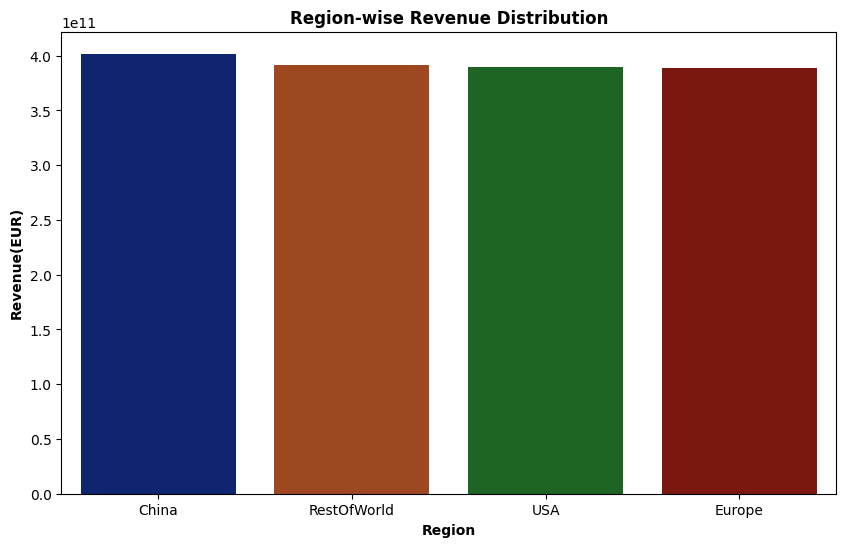

        Region   Revenue_EUR
0        China  401755020483
2  RestOfWorld  391071034606
3          USA  389314290428
1       Europe  388878952601


In [114]:
plt.figure(figsize = (10,6))
Region_Revenue = df.groupby('Region')['Revenue_EUR'].sum().reset_index()
Region_Revenue = Region_Revenue.sort_values(by='Revenue_EUR',ascending=False)
sns.barplot(
    data = Region_Revenue,
    x = 'Region',
    y = 'Revenue_EUR',
    palette = 'dark',
    hue = 'Region'
)
plt.title('Region-wise Revenue Distribution', fontweight = 'bold')
plt.xlabel('Region', fontweight = 'bold')
plt.ylabel('Revenue(EUR)', fontweight = 'bold')
plt.show()
print(Region_Revenue)

**Ques 8** Region-wise average price comparison kya hai?

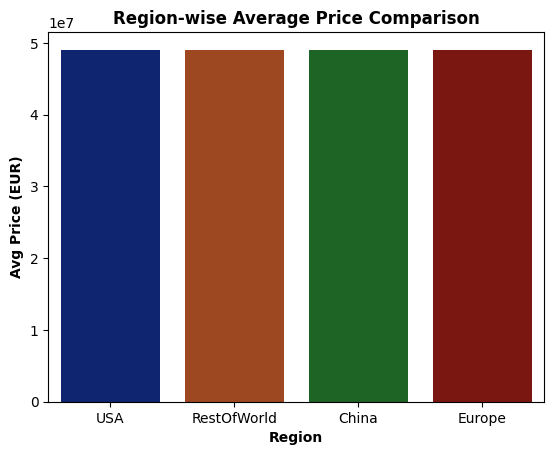

        Region  Avg_Price_EUR
3          USA       49062104
2  RestOfWorld       49059396
0        China       49034150
1       Europe       49005563


In [116]:
Average_Region_price = df.groupby('Region')['Avg_Price_EUR'].sum().reset_index()
Average_Region_price = Average_Region_price.sort_values(by='Avg_Price_EUR', ascending = False)
sns.barplot(
    data = Average_Region_price,
    x = 'Region',
    y = 'Avg_Price_EUR',
    palette = 'dark',
    hue = 'Region'
)
plt.title('Region-wise Average Price Comparison', fontweight = 'bold')
plt.xlabel('Region',fontweight = 'bold')
plt.ylabel('Avg Price (EUR)', fontweight = 'bold')
plt.show()
print(Average_Region_price)

**Ques9** Kaunsa region EV adoption (BEV Share) me fastest grow kar raha hai?

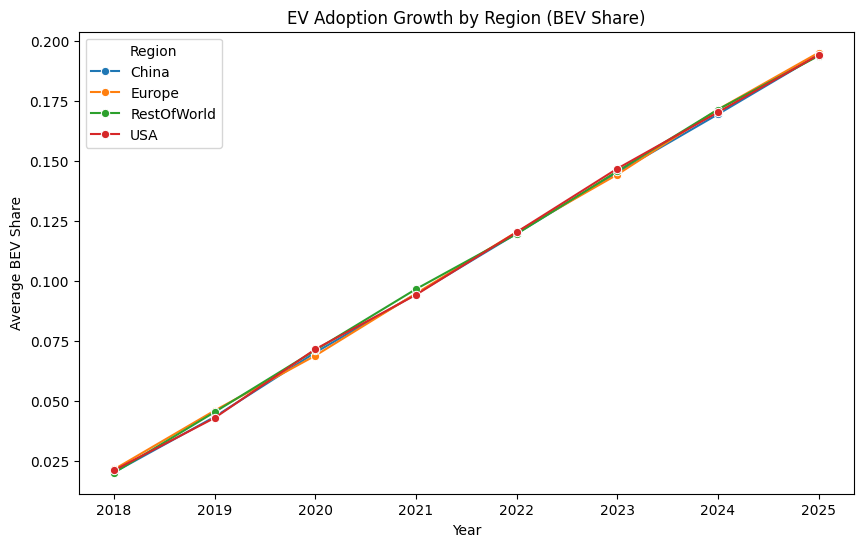

,min,max,Growth
Region,,,
China,-0.015,0.223,0.238
USA,-0.007,0.214,0.221
Europe,-0.002,0.218,0.220
RestOfWorld,-0.002,0.217,0.219


In [124]:
bev_growth = df.groupby(['Region','Year'])['BEV_Share'].mean().reset_index()
plt.figure(figsize=(10,6))

sns.lineplot(
    data=bev_growth,
    x='Year',
    y='BEV_Share',
    hue='Region',
    marker='o'
)

plt.title('EV Adoption Growth by Region (BEV Share)')
plt.ylabel('Average BEV Share')
plt.show()
bev_growth_region = df.groupby('Region')['BEV_Share'].agg(['min','max'])
bev_growth_region['Growth'] = bev_growth_region['max'] - bev_growth_region['min']

bev_growth_region.sort_values(by='Growth', ascending=False)

**Ques 10.** Top selling models kaunse hain?

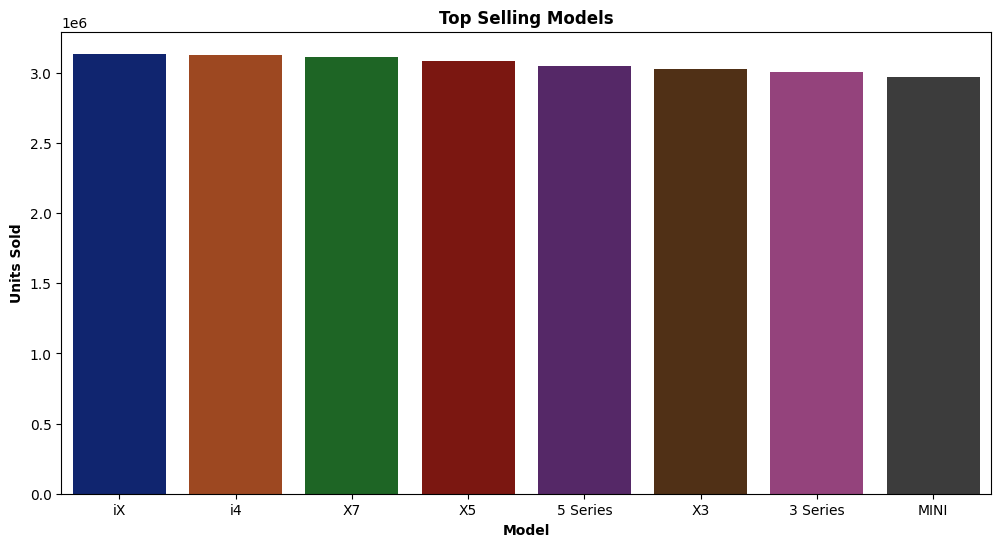

      Model  Units_Sold
7        iX     3136912
6        i4     3125687
5        X7     3112074
4        X5     3085134
1  5 Series     3052524


In [134]:
top_selling_model = df.groupby('Model')['Units_Sold'].sum().reset_index()
top_selling_model = top_selling_model.sort_values(by= 'Units_Sold', ascending = False)
plt.figure(figsize = (12,6))

sns.barplot(
    data = top_selling_model, 
    x = 'Model',
    y = 'Units_Sold',
    palette = 'dark',
    hue = 'Model'
)
plt.title("Top Selling Models", fontweight = 'bold')
plt.xlabel('Model',fontweight = 'bold')
plt.ylabel('Units Sold',fontweight = 'bold')
plt.show()
print(top_selling_model.head())

In [126]:
df.head(1)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0


**Ques 11.** Kaunsa model sabse zyada revenue generate karta hai?

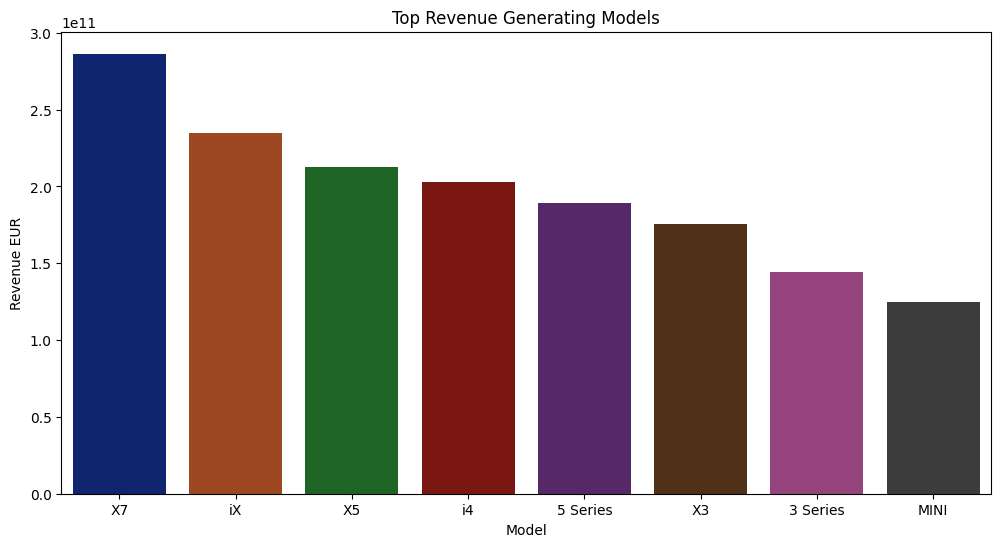

      Model   Revenue_EUR
5        X7  286427856714
7        iX  235060013889
4        X5  212814244305
6        i4  202904898753
1  5 Series  188992092821


In [137]:
model_revenue = df.groupby('Model')['Revenue_EUR'].sum().reset_index()
model_revenue = model_revenue.sort_values(by = 'Revenue_EUR', ascending = False)
plt.figure(figsize = (12,6))

sns.barplot(
    data = model_revenue,
    x = 'Model', 
    y = 'Revenue_EUR',
    palette = 'dark',
    hue = 'Model'
)
plt.title('Top Revenue Generating Models')
plt.xlabel('Model')
plt.ylabel('Revenue EUR')
plt.show()
print(model_revenue.head())

Ques . Model-wise average price kya hai?

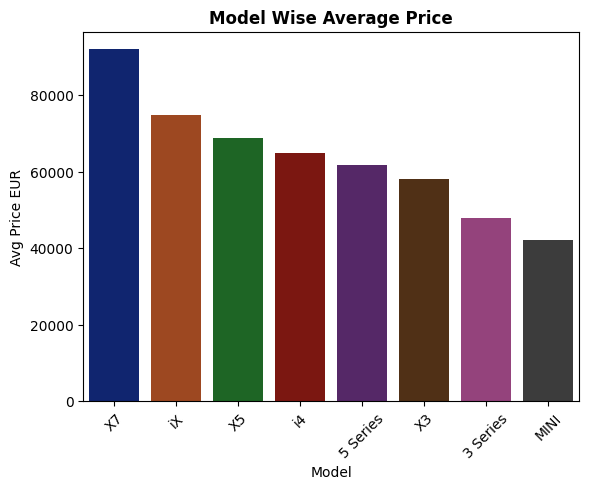

      Model  Avg_Price_EUR
5        X7        91937.0
7        iX        74900.0
4        X5        68871.5
6        i4        64847.0
1  5 Series        61858.5
3        X3        58114.0
0  3 Series        47968.5
2      MINI        42058.0


In [163]:
average_model_price = df.groupby('Model')['Avg_Price_EUR'].median().reset_index()
average_model_price = average_model_price.sort_values(by = 'Avg_Price_EUR' , ascending = False)
sns.barplot(
    data = average_model_price, 
    x = 'Model',
    y = 'Avg_Price_EUR',
    palette = 'dark',
    hue = 'Model'
)
plt.title('Model Wise Average Price', fontweight = 'bold')
plt.ylabel('Avg Price EUR')
plt.xticks(rotation = 45)
plt.show()
print(average_model_price.head(10))

Ques 13 : Model-wise BEV share kya hai?

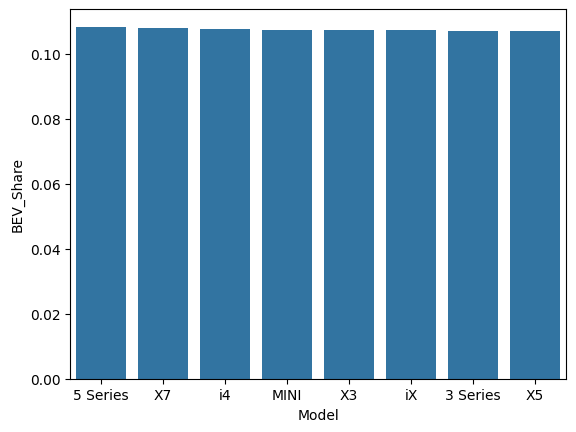

      Model  BEV_Share
1  5 Series   0.108385
5        X7   0.108044
6        i4   0.107667
2      MINI   0.107453
3        X3   0.107393
7        iX   0.107305
0  3 Series   0.107208
4        X5   0.107122


In [174]:
BEV_share_Model_wise = df.groupby('Model')['BEV_Share'].mean().reset_index()
BEV_share_Model_wise = BEV_share_Model_wise.sort_values(by='BEV_Share', ascending = False)

sns.barplot(
    data = BEV_share_Model_wise,
    x = 'Model',
    y = 'BEV_Share'
)
plt.show()
print(BEV_share_Model_wise)

Q. Average Price aur Units Sold ke beech relationship kya hai?

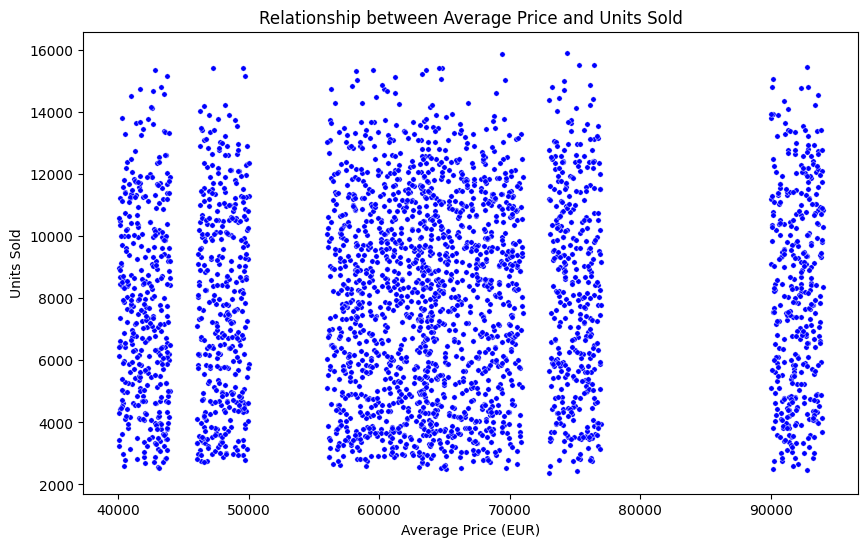

Correlation between Avg_Price_EUR and Units_Sold: 0.03916309888556895


In [188]:
plt.figure(figsize = (10,6))
sns.scatterplot(
    data = df,
    x = 'Avg_Price_EUR',
    y = 'Units_Sold',
    color = 'blue',
    s = 15
)
plt.title('Relationship between Average Price and Units Sold')
plt.xlabel('Average Price (EUR)')
plt.ylabel('Units Sold')
plt.show()
correlation = df['Avg_Price_EUR'].corr(df['Units_Sold'])
print("Correlation between Avg_Price_EUR and Units_Sold:", correlation)

In [175]:
df.head(1)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0


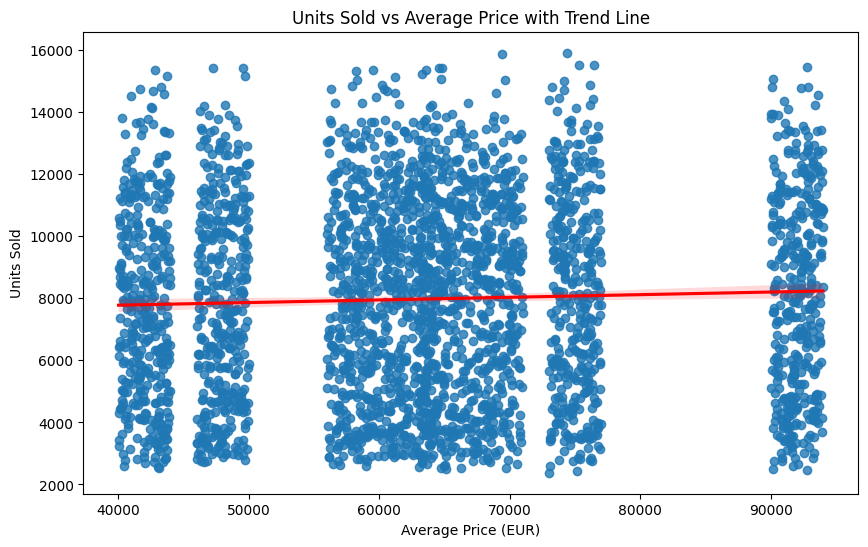

In [189]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Avg_Price_EUR',
    y='Units_Sold', 
    line_kws={'color':'red'}
)
plt.title('Units Sold vs Average Price with Trend Line')
plt.xlabel('Average Price (EUR)')
plt.ylabel('Units Sold')
plt.show()

Region-wise price variation kya hai?

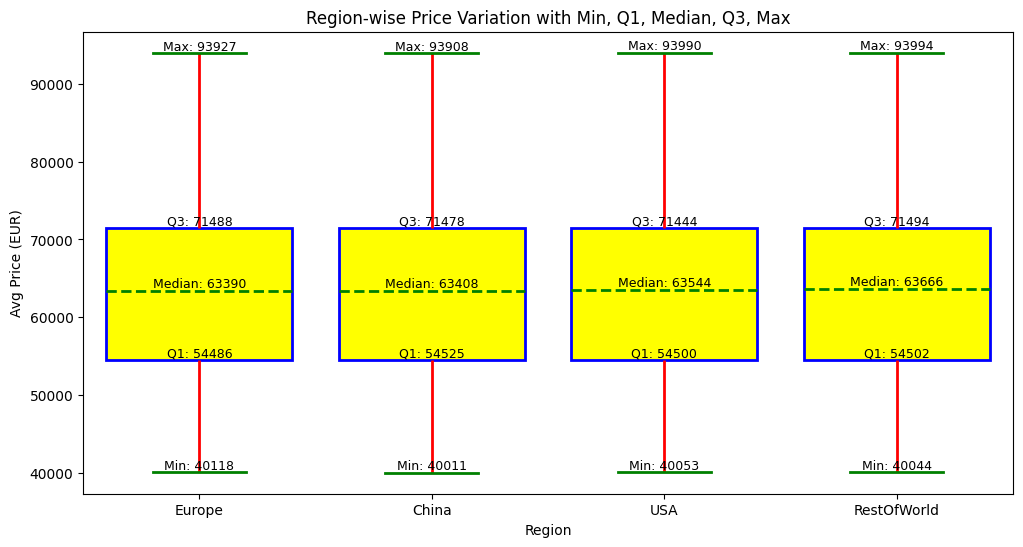

In [200]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12,6))
sns.boxplot(
    data = df,
    x = 'Region',
    y = 'Avg_Price_EUR',
    palette='pastel',
    hue = 'Region',
    patch_artist = True,
    boxprops = dict(facecolor = 'yellow', edgecolor = 'blue', linewidth = 2),
    medianprops=dict(color = 'green', linewidth = 2, linestyle = '--'),
    whiskerprops = dict(color = 'red', linewidth = 2),
    capprops = dict(color = 'green', linewidth = 2),
)

# Custom annotations
for i, region in enumerate(df['Region'].unique()):
    region_data = df[df['Region'] == region]['Avg_Price_EUR']
    q1 = np.percentile(region_data, 25)
    median = np.percentile(region_data, 50)
    q3 = np.percentile(region_data, 75)
    min_val = region_data.min()
    max_val = region_data.max()
    
    plt.text(i, min_val, f"Min: {min_val:.0f}", ha='center', va='bottom', fontsize=9)
    plt.text(i, q1, f"Q1: {q1:.0f}", ha='center', va='bottom', fontsize=9)
    plt.text(i, median, f"Median: {median:.0f}", ha='center', va='bottom', fontsize=9)
    plt.text(i, q3, f"Q3: {q3:.0f}", ha='center', va='bottom', fontsize=9)
    plt.text(i, max_val, f"Max: {max_val:.0f}", ha='center', va='bottom', fontsize=9)

plt.title('Region-wise Price Variation with Min, Q1, Median, Q3, Max')
plt.ylabel('Avg Price (EUR)')
plt.xlabel('Region')
plt.show()

BEV Share ka trend years ke saath kaise change ho raha hai?

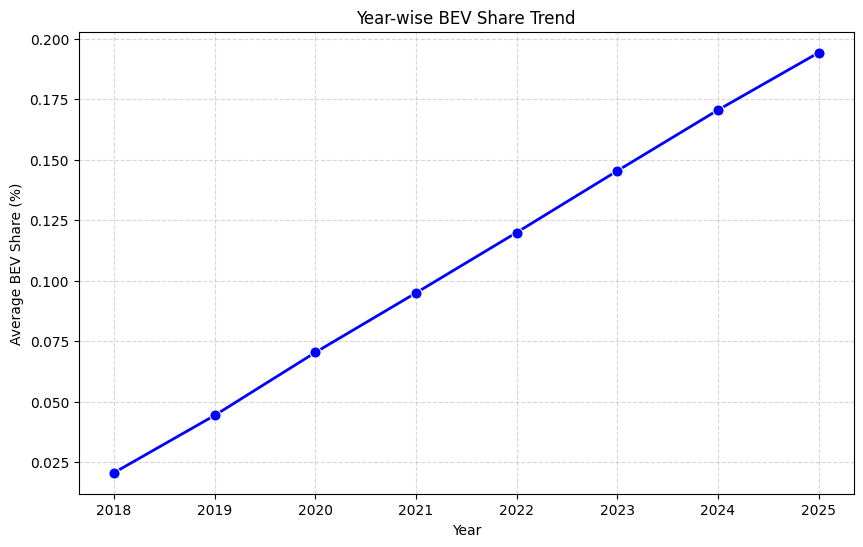

   Year  BEV_Share
0  2018   0.020654
1  2019   0.044349
2  2020   0.070372
3  2021   0.094969
4  2022   0.119945
5  2023   0.145432
6  2024   0.170581
7  2025   0.194276


In [205]:
bev_trend = df.groupby('Year')['BEV_Share'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(
    data=bev_trend,
    x='Year',
    y='BEV_Share',
    marker='o',
    linewidth=2,
    markersize=8,
    color='blue'
)
plt.title('Year-wise BEV Share Trend')
plt.ylabel('Average BEV Share (%)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print(bev_trend)

In [201]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


BEV share aur Units Sold ke beech relationship kya hai?

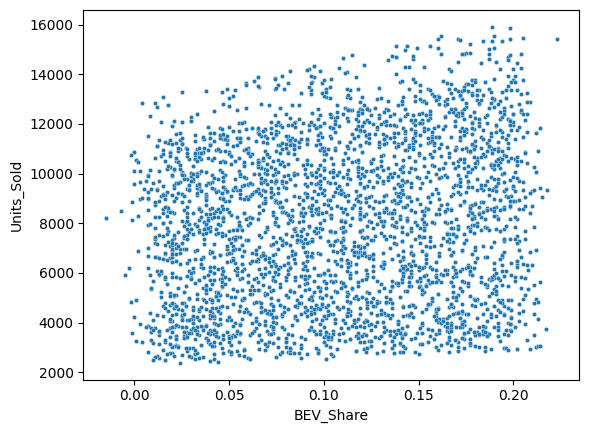

In [206]:
sns.scatterplot(
    data = df,
    x = 'BEV_Share',
    y = 'Units_Sold',
    s = 10
)
plt.show()

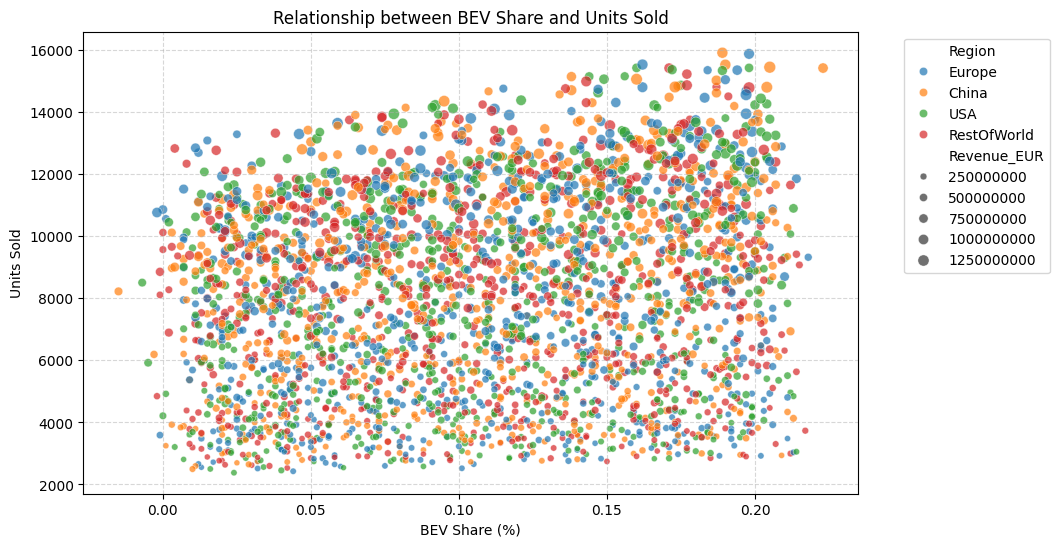

Correlation between BEV Share and Units Sold: 0.16


In [208]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='BEV_Share',
    y='Units_Sold',
    hue='Region',          # Different regions ko color se show kare
    size='Revenue_EUR',    # Revenue ke hisaab se dot size
    palette='tab10',
    alpha=0.7
)

plt.title('Relationship between BEV Share and Units Sold')
plt.xlabel('BEV Share (%)')
plt.ylabel('Units Sold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
corr = df['BEV_Share'].corr(df['Units_Sold'])
print(f"Correlation between BEV Share and Units Sold: {corr:.2f}")

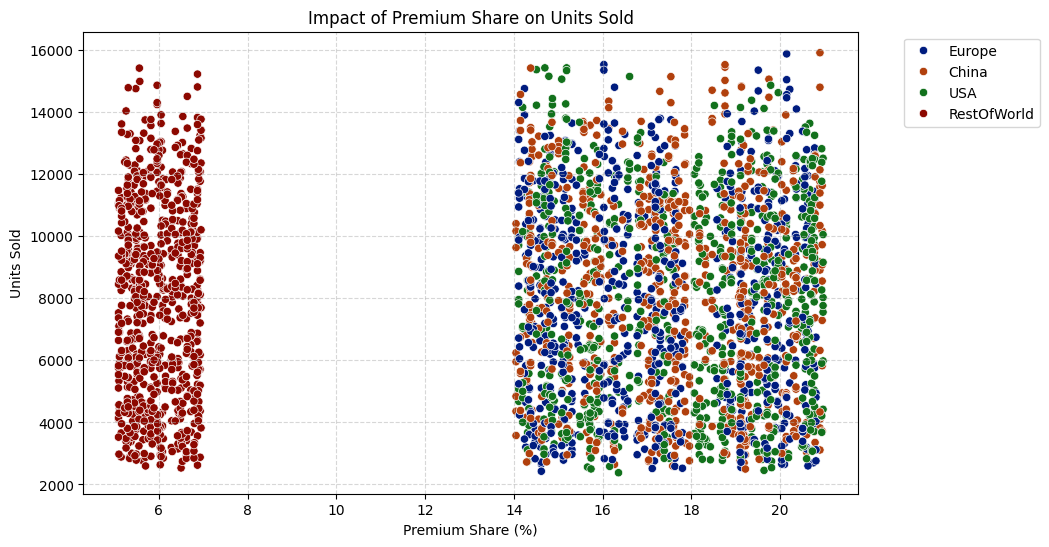

In [214]:


plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Premium_Share',
    y='Units_Sold',
    hue='Region',          # Region ke hisaab se color differentiate
    #size= 'Revenue_EUR',    # Revenue ke hisaab se dot size
    palette='dark',
    #alpha=0.7
)

plt.title('Impact of Premium Share on Units Sold')
plt.xlabel('Premium Share (%)')
plt.ylabel('Units Sold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

DP Growth ka vehicle sales par kya effect hai?

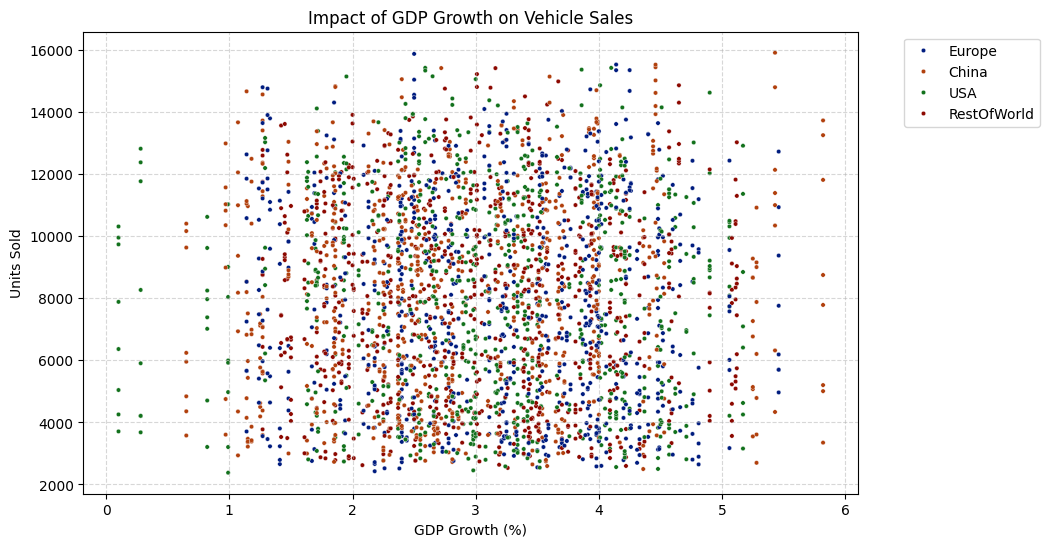

In [221]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='GDP_Growth',
    y='Units_Sold',
    hue='Region',          # Region-wise difference dikhane ke liye
    s = 10,   # Revenue ke hisaab se dot size
    palette='dark',
    #alpha=0.7
)

plt.title('Impact of GDP Growth on Vehicle Sales')
plt.xlabel('GDP Growth (%)')
plt.ylabel('Units Sold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

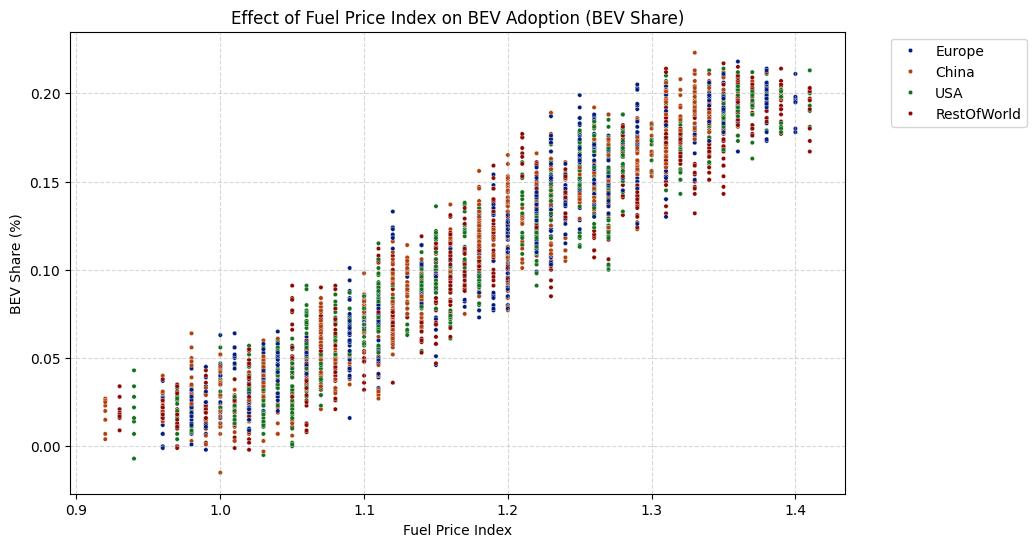

In [225]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Fuel_Price_Index',
    y='BEV_Share',
    hue='Region',       # Region-wise differences dikhane ke liye
    s =10,  # Units sold ka size
    palette='dark',
    #alpha=0.7
)

plt.title('Effect of Fuel Price Index on BEV Adoption (BEV Share)')
plt.xlabel('Fuel Price Index')
plt.ylabel('BEV Share (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

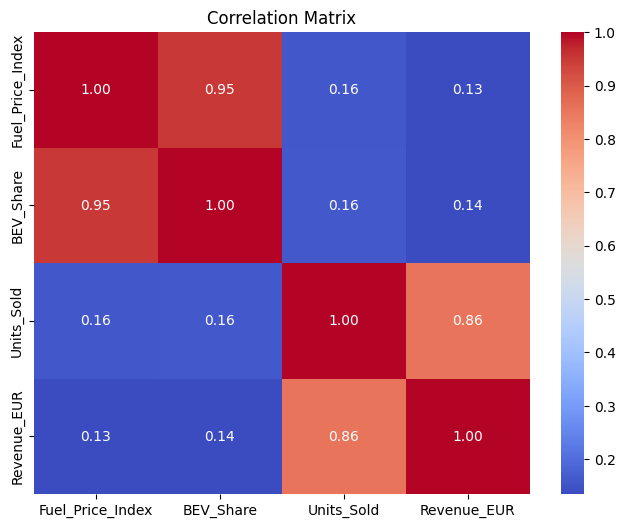

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
corr_matrix = df[['Fuel_Price_Index','BEV_Share','Units_Sold','Revenue_EUR']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [215]:
df.head(1)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
